<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/11-cnn-hyperparameter-tuning-keras-tuner/%D0%9F%D0%BE%D0%B4%D0%B1%D0%BE%D1%80_%D0%B3%D0%B8%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D0%BE%D0%B2_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Цель работы

Освоить применение сверточных нейронных сетей (CNN) для задач классификации изображений, а также изучить основные нюансы обучения моделей:

разделение данных на обучающую и валидационную выборки
анализ процесса обучения по графикам
выявление переобучения и недообучения
влияние архитектуры и гиперпараметров на качество модели

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [ ]:
# Названия классов из набора данных CIFAR-10
classes=['самолет', 'автомобиль', 'птица', 'кот', 'олень', 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

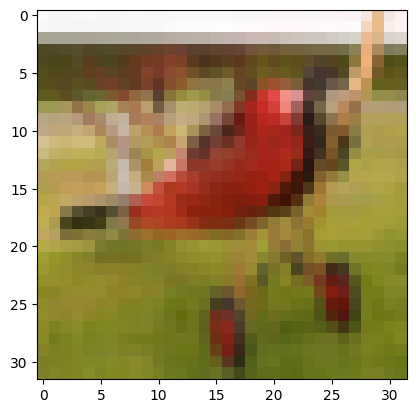

Номер класса: [0]
Тип объекта: самолет


In [ ]:
n = 35
plt.imshow(X_train[n])
plt.show()
print("Номер класса:", y_train[n])
print("Тип объекта:", classes[y_train[n][0]])

Шаг 2. Подготовьте данные

Нормализуйте изображения и преобразуйте метки классов.

Шаг 3. Разделите данные

Разделите обучающую выборку на обучающую и валидационную.

Шаг 4. Создайте сверточную нейронную сеть

Создайте модель с использованием сверточных слоев и слоев подвыборки.

Шаг 5. Скомпилируйте модель

Шаг 6. Обучите модель

Обучите модель с использованием валидационной выборки.

Шаг 7. Постройте графики обучения

Постройте графики точности и функции потерь.

Шаг 8. Оцените модель

Оцените качество модели на тестовой выборке.

Какую роль выполняет слой Conv2D в сверточной нейронной сети?


Какие признаки он извлекает из изображения?


Что означает параметр “количество фильтров” в слое Conv2D?


Как влияет увеличение числа фильтров на качество и сложность модели?


Что делает слой MaxPooling2D и зачем он используется после сверточных слоев?


Как изменяется размер данных после последовательного применения Conv2D и MaxPooling2D?
Почему это важно для обучения модели?


Зачем используется слой Flatten перед полносвязными слоями?


Как по графикам accuracy и loss определить переобучение модели?

Чем сверточные NN лучше полносвязных в работе с изображениями?

#7.2 Подбор архитектуры с помощью Keras Tuner

На предыдущих шагах была обучена одна фиксированная архитектура CNN.
Теперь попробуем подобрать более удачную архитектуру автоматически.

Для этого будем изменять:

количество фильтров в сверточных слоях;
количество нейронов в полносвязном слое;
значение Dropout;
скорость обучения optimizer.

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 13.8 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

Шаг 1. Создадайте функцию, которая будет строить модель с разными гиперпараметрами.

Функция build_model используется для создания сверточной нейронной сети с различными вариантами архитектуры. Она принимает объект hp (HyperParameters), который позволяет задавать различные значения гиперпараметров и автоматически перебирать их.

Внутри функции формируется архитектура модели, состоящая из нескольких блоков сверточных слоев (Conv2D) и слоев подвыборки (MaxPooling2D), а также полносвязного слоя (Dense) и слоя регуляризации (Dropout).

In [ ]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42
)


In [ ]:
def build_model(hp):
    model = keras.Sequential()

    model.add(layers.Input(shape=(32, 32, 3)))

    filters1 = hp.Int('filters1', min_value=32, max_value=128, step=32)
    model.add(layers.Conv2D(filters1, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    filters2 = hp.Int('filters2', min_value=64, max_value=256, step=64)
    model.add(layers.Conv2D(filters2, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    if hp.Boolean('third_block'):
        filters3 = hp.Int('filters3', min_value=128, max_value=512, step=128)
        model.add(layers.Conv2D(filters3, (3, 3), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    units = hp.Int('dense_units', min_value=64, max_value=512, step=64)
    model.add(layers.Dense(units, activation='relu'))

    dropout_rate = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation='softmax'))

    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Шаг 2. Создайте tuner.

Keras Tuner — это библиотека для автоматического подбора гиперпараметров нейронных сетей. Вместо ручного перебора архитектур, она автоматически:

строит различные варианты моделей;
обучает их;
оценивает качество на валидационной выборке;
выбирает лучшие конфигурации.

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_tuning_dir',
    project_name='cifar10_tuning'
)

tuner.search_space_summary()

Search space summary
Default search space size: 6
filters1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
filters2 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
third_block (Boolean)
{'default': False, 'conditions': []}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 512, 'step': 64, 'sampling': 'linear'}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


Шаг 3. Запустите подбор гиперпараметров.

Метод tuner.search запускает процесс подбора гиперпараметров. Для каждой комбинации параметров:

создаётся новая модель;
модель обучается на обучающей выборке;
оценивается на валидационной выборке;
сохраняются результаты (например, val_accuracy).

В итоге формируется список лучших моделей.

ВАЖНО! Не забудьте сменить среду выполнения для ускорения обучения

В среде Google Colab пользователю по умолчанию предоставляется доступ к вычислительным ресурсам в облаке, включая центральный процессор (CPU), а также возможность использовать графический процессор (GPU) для ускорения обучения моделей. В бесплатной версии Colab чаще всего выделяется GPU типа NVIDIA T4, который специально предназначен для задач машинного обучения и способен значительно ускорять вычисления по сравнению с CPU . GPU в Colab не включён автоматически — по умолчанию используется CPU, и для ускорения обучения необходимо вручную выбрать GPU в настройках среды выполнения (Runtime → Change runtime type → GPU).

In [ ]:
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Trial 10 Complete [00h 01m 13s]
val_accuracy: 0.6988000273704529

Best val_accuracy So Far: 0.7670999765396118
Total elapsed time: 00h 10m 39s


Шаг 4. Отобразите  5 лучших вариантов.

In [ ]:
best_trials = tuner.oracle.get_best_trials(5)

for i, trial in enumerate(best_trials):
    print(f"\n {i+1} место")
    print(f"val_accuracy: {trial.score:.4f}")
    print(f"Гиперпараметры:")
    for key, value in trial.hyperparameters.values.items():
        print(f"      {key}: {value}")


 1 место
   val_accuracy: 0.7729
   Гиперпараметры:
      filters1: 32
      filters2: 128
      third_block: True
      dense_units: 384
      dropout: 0.4
      learning_rate: 0.001
      filters3: 512

 2 место
   val_accuracy: 0.7677
   Гиперпараметры:
      filters1: 32
      filters2: 128
      third_block: True
      dense_units: 256
      dropout: 0.4
      learning_rate: 0.001
      filters3: 512

 3 место
   val_accuracy: 0.7657
   Гиперпараметры:
      filters1: 32
      filters2: 128
      third_block: True
      dense_units: 448
      dropout: 0.4
      learning_rate: 0.001
      filters3: 128

 4 место
   val_accuracy: 0.7382
   Гиперпараметры:
      filters1: 64
      filters2: 192
      third_block: False
      dense_units: 384
      dropout: 0.30000000000000004
      learning_rate: 0.001
      filters3: 384

 5 место
   val_accuracy: 0.7358
   Гиперпараметры:
      filters1: 32
      filters2: 128
      third_block: False
      dense_units: 448
      dropout: 0.2
    

Шаг 5. Отобразите summary для топ-5 моделей.

In [ ]:
best_trials = tuner.oracle.get_best_trials(5)

for i, trial in enumerate(best_trials):
    print(f"МОДЕЛЬ №{i+1} (val_accuracy: {trial.score:.4f})")

    model = tuner.hypermodel.build(trial.hyperparameters)

    model.summary()

    print(f"\nГиперпараметры:")
    for key, value in trial.hyperparameters.values.items():
        print(f"{key}: {value}")



МОДЕЛЬ №1 (val_accuracy: 0.7729)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 512)      │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 384)            │     3,146,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,778,186 (14.41 MB)

 Trainable params: 3,778,186 (14.41 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 448)            │     3,670,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         4,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,712,842 (14.16 MB)

 Trainable params: 3,712,842 (14.16 MB)

 Non-trainable params: 0 (0.00 B)


Гиперпараметры:
  → filters1: 32
  → filters2: 128
  → third_block: False
  → dense_units: 448
  → dropout: 0.2
  → learning_rate: 0.001


Шаг 6. Проверьте качество каждой модели на тестовой выборке.

Функция model.evaluate используется для оценки качества модели на тестовой выборке.

Она возвращает:

значение функции потерь (loss);
значение метрики (в данном случае accuracy).

In [ ]:
best_trials = tuner.oracle.get_best_trials(5)

results = []

for i, trial in enumerate(best_trials):
    print(f"\n Тестируем модель №{i+1}...")
    print(f"   val_accuracy (по данным tuner): {trial.score:.4f}")

    model = tuner.hypermodel.build(trial.hyperparameters)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"Тестовая точность: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"Тестовый loss: {test_loss:.4f}")

    results.append({
        'place': i+1,
        'val_accuracy': trial.score,
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'hyperparameters': trial.hyperparameters.values
    })
    print("-"*50)


 Тестируем модель №1...
   val_accuracy (по данным tuner): 0.7729
Тестовая точность: 0.1176 (11.76%)
Тестовый loss: 2.3066
--------------------------------------------------

 Тестируем модель №2...
   val_accuracy (по данным tuner): 0.7677
Тестовая точность: 0.0999 (9.99%)
Тестовый loss: 2.3046
--------------------------------------------------

 Тестируем модель №3...
   val_accuracy (по данным tuner): 0.7657
Тестовая точность: 0.1012 (10.12%)
Тестовый loss: 2.3054
--------------------------------------------------

 Тестируем модель №4...
   val_accuracy (по данным tuner): 0.7382
Тестовая точность: 0.0989 (9.89%)
Тестовый loss: 2.3055
--------------------------------------------------

 Тестируем модель №5...
   val_accuracy (по данным tuner): 0.7358
Тестовая точность: 0.0998 (9.98%)
Тестовый loss: 2.3133
--------------------------------------------------


Шаг 7. Выберите лучшую модель.

In [ ]:
best_trials = tuner.oracle.get_best_trials(5)

test_results = []

for i, trial in enumerate(best_trials):
    model = tuner.hypermodel.build(trial.hyperparameters)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    test_results.append({
        'model_num': i + 1,
        'val_acc': trial.score,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'params': trial.hyperparameters.values
    })

    print(f"Модель #{i+1}: val_acc={trial.score:.4f}, test_acc={test_acc:.4f}")

best_model_result = max(test_results, key=lambda x: x['test_acc'])
print(f"Номер модели: #{best_model_result['model_num']}")

Модель #1: val_acc=0.7729, test_acc=0.0978
Модель #2: val_acc=0.7677, test_acc=0.1000
Модель #3: val_acc=0.7657, test_acc=0.0915
Модель #4: val_acc=0.7382, test_acc=0.0860
Модель #5: val_acc=0.7358, test_acc=0.0993
Номер модели: #2


Дополнительные эксперименты

Для повышения качества модели рекомендуется самостоятельно провести дополнительные эксперименты:

увеличить количество эпох обучения (например, до 20–30), чтобы модель лучше обучилась;
увеличить количество испытаний в Keras Tuner (max_trials), чтобы рассмотреть больше вариантов архитектур;
расширить пространство гиперпараметров, например:
добавить новые значения числа фильтров;
изменить размер полносвязного слоя;
добавить новые сверточные слои;

In [ ]:
!pip install keras-tuner

import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42
)

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(32, 32, 3)))

    filters1 = hp.Int('filters1', 16, 128, 16)
    model.add(layers.Conv2D(filters1, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(filters1, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(hp.Float('dropout1', 0.1, 0.3, 0.1)))

    filters2 = hp.Int('filters2', 32, 256, 32)
    model.add(layers.Conv2D(filters2, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(filters2, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(hp.Float('dropout2', 0.2, 0.4, 0.1)))

    if hp.Boolean('third_block'):
        filters3 = hp.Int('filters3', 64, 512, 64)
        model.add(layers.Conv2D(filters3, (3, 3), activation='relu', padding='same'))
        model.add(layers.Conv2D(filters3, (3, 3), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(hp.Float('dropout3', 0.3, 0.5, 0.1)))

    model.add(layers.Flatten())

    units = hp.Int('dense_units', 128, 1024, 128)
    model.add(layers.Dense(units, activation='relu'))
    model.add(layers.Dropout(hp.Float('dropout_dense', 0.3, 0.6, 0.1)))

    model.add(layers.Dense(10, activation='softmax'))

    lr = hp.Choice('learning_rate', [0.001, 0.0005, 0.0001])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=15,
    executions_per_trial=1,
    directory='my_tuning_dir',
    project_name='cifar10_expanded'
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    verbose=1
)

print("\n--- Лучшая модель ---")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

print("\nSummary лучшей модели:")
best_model.summary()

history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print("\nТестовая точность лучшей модели:", test_acc)
print("Тестовые потери лучшей модели:", test_loss)

print("\nЛучшие гиперпараметры:")
for param, value in best_hps.values.items():
    print(f"  {param}: {value}")


Trial 9 Complete [00h 03m 35s]
val_accuracy: 0.7753000259399414

Best val_accuracy So Far: 0.8133999705314636
Total elapsed time: 00h 26m 00s

Search: Running Trial #10

Value             |Best Value So Far |Hyperparameter
128               |64                |filters1
0.1               |0.2               |dropout1
224               |128               |filters2
0.3               |0.4               |dropout2
True              |True              |third_block
128               |768               |dense_units
0.4               |0.4               |dropout_dense
0.0005            |0.0005            |learning_rate
384               |64                |filters3
0.5               |0.3               |dropout3

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.3256 - loss: 1.7978 - val_accuracy: 0.4825 - val_loss: 1.4127
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.5433 - loss: 1.2686 - val_accuracy: 0.6357 - val_loss: 1.0156
Epoch 3/15
625/625 ━━━━━━━━━━━